In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import numpy as np

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Lending Club/LC_loans_granting_model_dataset.csv')

/tmp/ipykernel_8421/1808724376.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Lending Club/LC_loans_granting_model_dataset.csv')


In [3]:
df.head()

,id,issue_d,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length,purpose,home_ownership_n,addr_state,zip_code,Default,title,desc
0,68407277,Dec-2015,55000.0,5.91,3600,677.0,1,10+ years,debt_consolidation,MORTGAGE,PA,190xx,0,Debt consolidation,NaN
1,68355089,Dec-2015,65000.0,16.06,24700,717.0,1,10+ years,small_business,MORTGAGE,SD,577xx,0,Business,NaN
2,68341763,Dec-2015,71000.0,13.85,20000,697.0,1,10+ years,home_improvement,MORTGAGE,IL,605xx,0,NaN,NaN
3,68476807,Dec-2015,104433.0,25.37,10400,697.0,1,3 years,major_purchase,MORTGAGE,PA,174xx,0,Major purchase,NaN
4,68426831,Dec-2015,34000.0,10.20,11950,692.0,1,4 years,debt_consolidation,RENT,GA,300xx,0,Debt consolidation,NaN


In [4]:
df.shape

(1347681, 15)

In [5]:
df.isnull().sum()

,0
id,0
issue_d,0
revenue,0
dti_n,0
loan_amnt,0
fico_n,0
experience_c,0
emp_length,0
purpose,0
home_ownership_n,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1347681 entries, 0 to 1347680
Data columns (total 15 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1347681 non-null  int64  
 1   issue_d           1347681 non-null  object 
 2   revenue           1347681 non-null  float64
 3   dti_n             1347681 non-null  float64
 4   loan_amnt         1347681 non-null  int64  
 5   fico_n            1347681 non-null  float64
 6   experience_c      1347681 non-null  int64  
 7   emp_length        1347681 non-null  object 
 8   purpose           1347681 non-null  object 
 9   home_ownership_n  1347681 non-null  object 
 10  addr_state        1347681 non-null  object 
 11  zip_code          1347680 non-null  object 
 12  Default           1347681 non-null  int64  
 13  title             1331024 non-null  object 
 14  desc              119099 non-null   object 
dtypes: float64(3), int64(4), object(8)
memory usage: 

In [7]:
mapping = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,'5 years': 5,'6 years': 6, '7 years': 7,
           '8 years': 8,'9 years': 9, '10+ years': 10}
df['emp_length_encoded'] = df['emp_length'].map(mapping)

In [8]:
df.isnull().sum()

,0
id,0
issue_d,0
revenue,0
dti_n,0
loan_amnt,0
fico_n,0
experience_c,0
emp_length,0
purpose,0
home_ownership_n,0


In [9]:
df.emp_length_encoded.fillna(df.emp_length_encoded.mode()[0].astype('int'),inplace=True)

/tmp/ipykernel_8421/1635088817.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.emp_length_encoded.fillna(df.emp_length_encoded.mode()[0].astype('int'),inplace=True)


In [10]:
df[df['emp_length']=='NI']

,id,issue_d,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length,purpose,home_ownership_n,addr_state,zip_code,Default,title,desc,emp_length_encoded
60,68416953,Dec-2015,45000.0,16.11,1500,747.0,1,NI,vacation,MORTGAGE,HI,967xx,0,Vacation,NaN,10.0
77,68377020,Dec-2015,80000.0,20.18,15000,777.0,1,NI,debt_consolidation,RENT,VA,236xx,0,Debt consolidation,NaN,10.0
117,68516545,Dec-2015,132000.0,13.83,25000,747.0,1,NI,debt_consolidation,MORTGAGE,MI,498xx,0,Debt consolidation,NaN,10.0
119,68446591,Dec-2015,16488.0,38.06,2500,772.0,1,NI,debt_consolidation,RENT,CT,064xx,0,Debt consolidation,NaN,10.0
123,68537498,Dec-2015,45000.0,10.67,15000,712.0,1,NI,debt_consolidation,MORTGAGE,CA,913xx,0,Debt consolidation,NaN,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1347498,90238481,Oct-2016,30000.0,19.04,10000,672.0,1,NI,credit_card,RENT,CA,900xx,1,Credit card refinancing,NaN,10.0
1347500,90241151,Oct-2016,100000.0,17.70,20000,732.0,1,NI,credit_card,MORTGAGE,NY,140xx,0,Credit card refinancing,NaN,10.0
1347509,90041121,Oct-2016,38000.0,27.48,16700,692.0,1,NI,debt_consolidation,MORTGAGE,CO,809xx,0,Debt consolidation,NaN,10.0
1347608,90195681,Oct-2016,18876.0,12.84,6400,672.0,1,NI,debt_consolidation,MORTGAGE,NY,114xx,0,Debt consolidation,NaN,10.0


In [11]:
df = df.drop(columns=['emp_length'])

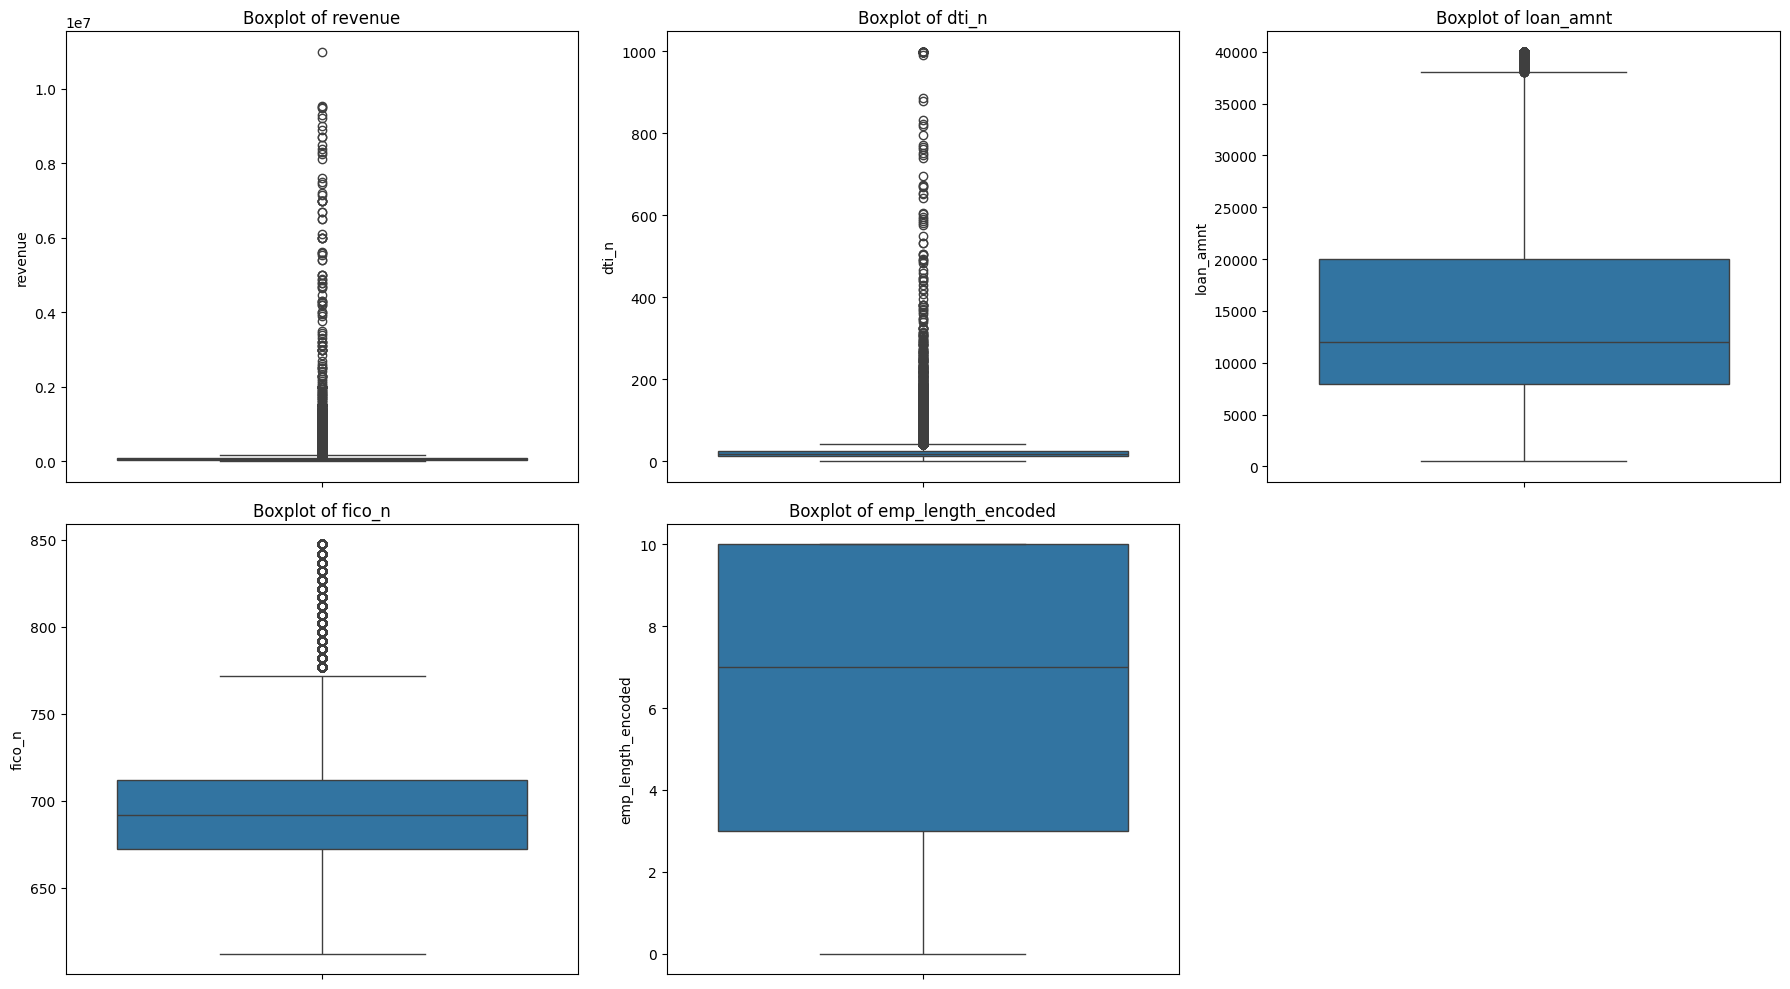

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for outlier detection
numerical_cols = [
    'revenue',
    'dti_n',
    'loan_amnt',
    'fico_n',
    'emp_length_encoded'
]

# Calculate number of rows and columns for subplots
num_cols = len(numerical_cols)
plots_per_row = 3 # Desired number of plots per row
num_rows = (num_cols + plots_per_row - 1) // plots_per_row # Ceiling division for rows

plt.figure(figsize=(plots_per_row * 6, num_rows * 5))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, plots_per_row, i + 1) # (rows, columns, current_plot_index)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

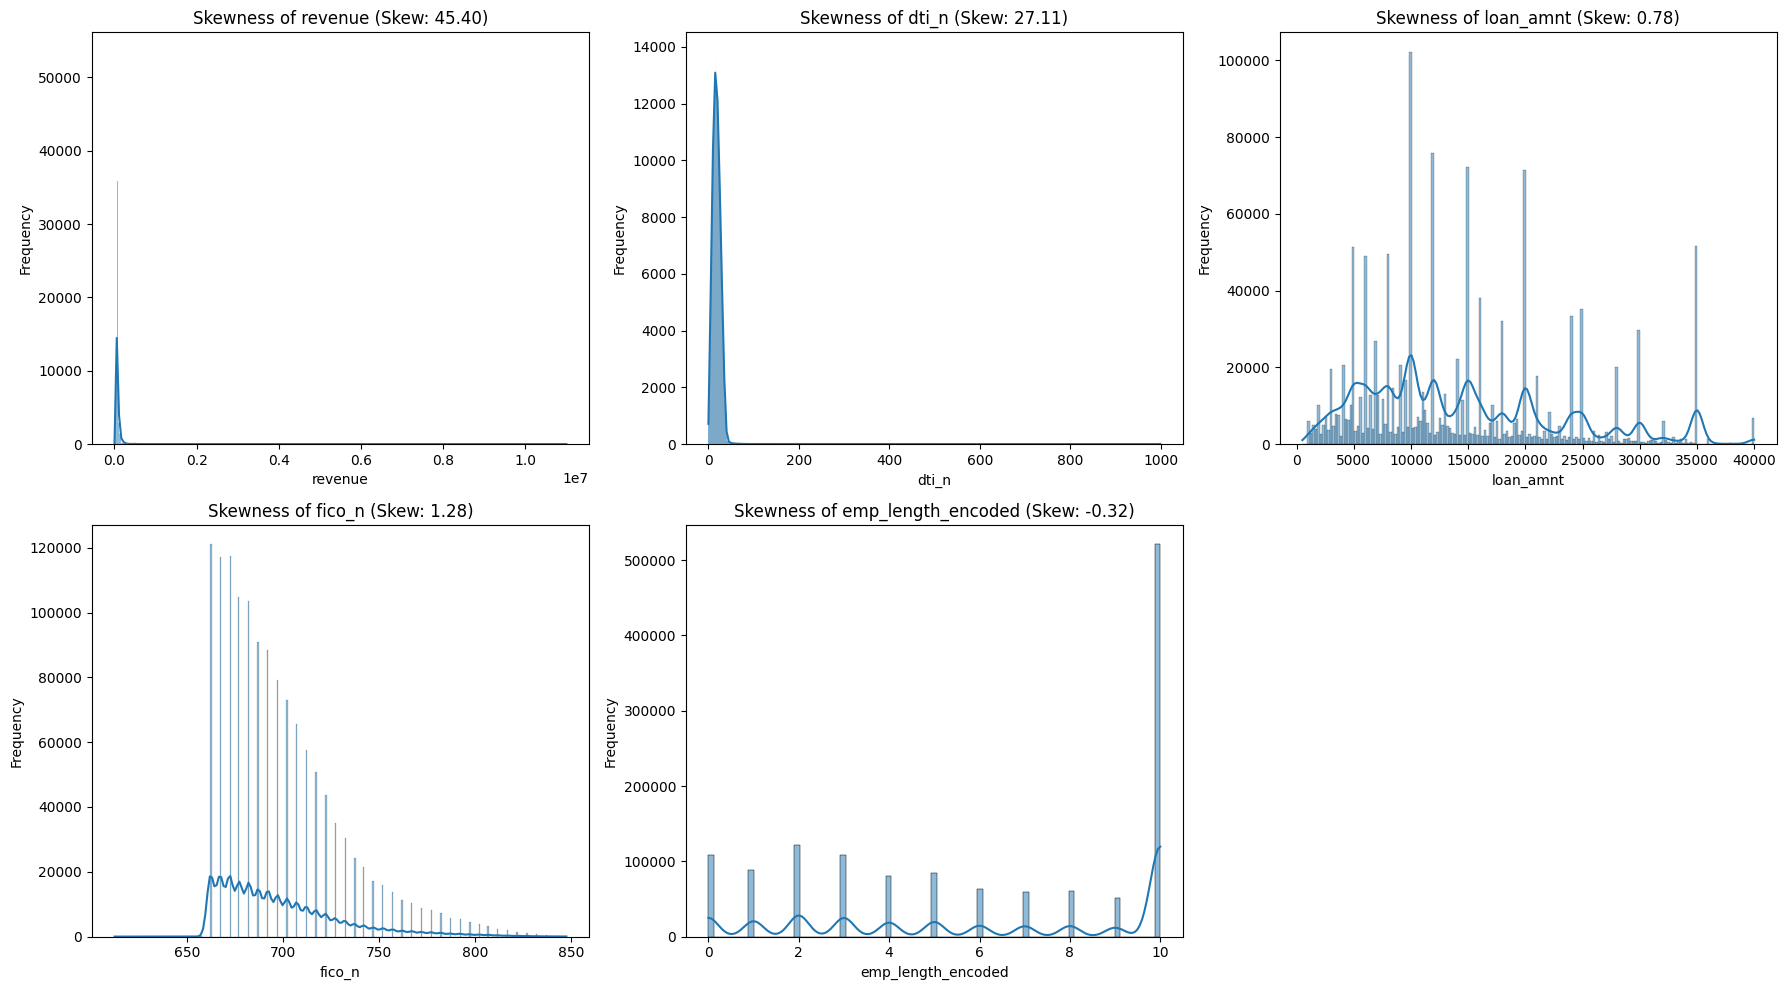

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Eligible numerical columns for skewness analysis
numerical_cols = [
    'revenue',
    'dti_n',
    'loan_amnt',
    'fico_n',
    'emp_length_encoded'
]

# Determine the number of rows needed for 3 plots per row
plots_per_row = 3
num_plots = len(numerical_cols)
num_rows = (num_plots + plots_per_row - 1) // plots_per_row # Ceiling division

plt.figure(figsize=(plots_per_row * 6, num_rows * 5))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, plots_per_row, i + 1)
    sns.histplot(df[col], kde=True) # Using histplot with KDE for distribution and skewness visualization
    plt.title(f'Skewness of {col} (Skew: {df[col].skew():.2f})')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [14]:
print(df[['revenue', 'dti_n', 'loan_amnt', 'fico_n']].describe())

            revenue         dti_n     loan_amnt        fico_n
count  1.347681e+06  1.347681e+06  1.347681e+06  1.347681e+06
mean   7.736968e+04  1.829909e+01  1.440823e+04  6.981589e+02
std    7.036299e+04  1.115214e+01  8.715347e+03  3.184872e+01
min    1.896000e+03  0.000000e+00  5.000000e+02  6.120000e+02
25%    4.660000e+04  1.182000e+01  7.975000e+03  6.720000e+02
50%    6.500000e+04  1.763000e+01  1.200000e+04  6.920000e+02
75%    9.200000e+04  2.407000e+01  2.000000e+04  7.120000e+02
max    1.099920e+07  9.990000e+02  4.000000e+04  8.475000e+02


In [15]:
import numpy as np
df.loc[df['dti_n'] > 100, 'dti_n'] = np.nan

In [16]:
# Cap revenue at the 99.9th percentile to remove crazy outliers
revenue_ceil = df['revenue'].quantile(0.999)
df['revenue'] = np.where(df['revenue'] > revenue_ceil, revenue_ceil, df['revenue'])

In [17]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 5.8 MB/s eta 0:00:00


In [18]:
print("No. Unique values in purpose: ",df.purpose.nunique())
print("No. Unique values in home ownership: ",df.home_ownership_n.nunique())

No. Unique values in purpose:  14
No. Unique values in home ownership:  4


In [19]:
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
encoder = ohe.fit_transform(df[['purpose','home_ownership_n']])
encoded_df = pd.DataFrame(encoder,columns = ohe.get_feature_names_out(['purpose','home_ownership_n']))

In [20]:
df = pd.concat([df.drop(columns=['purpose','home_ownership_n']).reset_index(drop=True),
                encoded_df.reset_index(drop=True)], axis=1)

In [21]:
df.head()

,id,issue_d,revenue,dti_n,loan_amnt,fico_n,experience_c,addr_state,zip_code,Default,...,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,home_ownership_n_MORTGAGE,home_ownership_n_OTHER,home_ownership_n_OWN,home_ownership_n_RENT
0,68407277,Dec-2015,55000.0,5.91,3600,677.0,1,PA,190xx,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,68355089,Dec-2015,65000.0,16.06,24700,717.0,1,SD,577xx,0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,68341763,Dec-2015,71000.0,13.85,20000,697.0,1,IL,605xx,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,68476807,Dec-2015,104433.0,25.37,10400,697.0,1,PA,174xx,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,68426831,Dec-2015,34000.0,10.20,11950,692.0,1,GA,300xx,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [22]:
print("No. Unique values in issue date: ",df.issue_d.nunique())
print("No. Unique values in home title: ",df.title.nunique())
print("No. Unique values in home description: ",df.desc.nunique())

No. Unique values in issue date:  139
No. Unique values in home title:  61451
No. Unique values in home description:  109539


In [23]:
# Convert to string and handle text metadata
for col in ['title', 'desc']:
    # Create binary column indicating if text is missing
    df[f'has_{col}'] = df[col].notna().astype(int)

    # Fill NaN with empty string to calculate length safely
    df[col] = df[col].fillna("")

    # Create a feature for text length
    df[f'{col}_len'] = df[col].apply(len)

# Drop the original massive string columns so they don't break the model
df = df.drop(columns=['title', 'desc'])

In [24]:
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
# Extract year and month as numeric features
df['issue_year'] = df['issue_d'].dt.year
df['issue_month'] = df['issue_d'].dt.month

# Creating a continuous timeline feature (months since the earliest loan)
min_date = df['issue_d'].min()
df['issue_trend_index'] = ((df['issue_d'].dt.year - min_date.year) * 12 +
                           (df['issue_d'].dt.month - min_date.month))

# Drop the unwanted features before training
df = df.drop(columns=['issue_d'])
df = df.drop(columns=['id'])

In [25]:
df = df.dropna()

In [26]:
df.Default.value_counts()

,count
Default,
0,1078041
1,269106


In [27]:
print("No. Unique values in State: ",df.addr_state.nunique())
print("No. Unique values in Zipcode: ",df.zip_code.nunique())

No. Unique values in State:  51
No. Unique values in Zipcode:  945


In [28]:
# Creating New Features
df_engineered = df.copy()

# 1. Debt-to-Income to Loan Ratio (Captures leverage intensity)
df_engineered['loan_to_revenue'] = df_engineered['loan_amnt'] / (df_engineered['revenue'] + 1)

# 2. Risk Exposure Index (Combines FICO vulnerability with loan size)
df_engineered['fico_per_dollar'] = df_engineered['fico_n'] / (df_engineered['loan_amnt'] + 1)

# 3. Available Financial Buffer Proxy
# High DTI + High Loan Amount means razor-thin safety margins
df_engineered['debt_stress_index'] = df_engineered['dti_n'] * df_engineered['loan_amnt']

# 4. Text Transparency Score
# Legitimate borrowers typically write detailed titles and descriptions
df_engineered['text_transparency'] = df_engineered['title_len'] + df_engineered['desc_len']


In [29]:
df_engineered.columns

Index(['revenue', 'dti_n', 'loan_amnt', 'fico_n', 'experience_c', 'addr_state',
       'zip_code', 'Default', 'emp_length_encoded', 'purpose_car',
       'purpose_credit_card', 'purpose_debt_consolidation',
       'purpose_educational', 'purpose_home_improvement', 'purpose_house',
       'purpose_major_purchase', 'purpose_medical', 'purpose_moving',
       'purpose_other', 'purpose_renewable_energy', 'purpose_small_business',
       'purpose_vacation', 'purpose_wedding', 'home_ownership_n_MORTGAGE',
       'home_ownership_n_OTHER', 'home_ownership_n_OWN',
       'home_ownership_n_RENT', 'has_title', 'title_len', 'has_desc',
       'desc_len', 'issue_year', 'issue_month', 'issue_trend_index',
       'loan_to_revenue', 'fico_per_dollar', 'debt_stress_index',
       'text_transparency'],
      dtype='object')

In [30]:
import category_encoders as ce
from sklearn.model_selection import train_test_split

# Separate Features and Target
X = df_engineered.drop(columns=['Default'])
y = df_engineered['Default']

# Split into Train and a Temporary "Remaining" Set
# This separates 80% of the data for training, and leaves 20% to be split later.
X_train, X_rem, y_train, y_rem = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Split the Remaining 20% equally into Validation and Test
# test_size=0.5 means half of 20% goes to Validation (10%) and half to Test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_rem, y_rem,
    test_size=0.50,
    random_state=42,
    stratify=y_rem
)

print(f"Train size:      {X_train.shape[0]} rows")
print(f"Validation size: {X_val.shape[0]} rows")
print(f"Test size:       {X_test.shape[0]} rows")


# Handle Target Encoding Safe from Data Leakage
geo_encoder = ce.TargetEncoder(cols=['addr_state', 'zip_code'])

X_train_encoded = geo_encoder.fit_transform(X_train, y_train)


X_val_encoded = geo_encoder.transform(X_val)
X_test_encoded = geo_encoder.transform(X_test)

Train size:      1077717 rows
Validation size: 134715 rows
Test size:       134715 rows


In [31]:
import numpy as np
import pandas as pd
import category_encoders as ce
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


# Calculate Class Imbalance Weight ---
# count of negative class (0) / count of positive class (1)
num_negative = np.sum(y_train == 0)
num_positive = np.sum(y_train == 1)
imbalance_weight = num_negative / num_positive

print(f"Dataset Scale Weight calculated: {imbalance_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=imbalance_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='aucpr',
    early_stopping_rounds=30,
    random_state=42
)


xgb_model.fit(
    X_train_encoded, y_train,
    eval_set=[(X_val_encoded, y_val)],
    verbose=50
)


Dataset Scale Weight calculated: 4.01
[0]	validation_0-aucpr:0.30564
[50]	validation_0-aucpr:0.33690
[100]	validation_0-aucpr:0.34053
[150]	validation_0-aucpr:0.34206
[200]	validation_0-aucpr:0.34307
[250]	validation_0-aucpr:0.34355
[300]	validation_0-aucpr:0.34391
[350]	validation_0-aucpr:0.34420
[400]	validation_0-aucpr:0.34430
[450]	validation_0-aucpr:0.34456
[500]	validation_0-aucpr:0.34466
[550]	validation_0-aucpr:0.34473
[600]	validation_0-aucpr:0.34479
[650]	validation_0-aucpr:0.34479
[658]	validation_0-aucpr:0.34482


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=30,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

In [34]:
import joblib
joblib.dump(xgb_model, 'lendingclub_1.0.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
import lightgbm as lgb
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=8,
    num_leaves=64,
    min_child_samples=15,
    scale_pos_weight=imbalance_weight,
    subsample=0.8,
    colsample_bytree=0.7,
    objective='binary',
    metric='auc',
    random_state=42,
    n_jobs=-1
)

# Fit model using explicit early stopping criteria
lgb_model.fit(
    X_train_encoded, y_train,
    eval_set=[(X_val_encoded, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

[LightGBM] [Info] Number of positive: 215285, number of negative: 862432
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.171906 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2658
[LightGBM] [Info] Number of data points in the train set: 1077717, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199760 -> initscore=-1.387794
[LightGBM] [Info] Start training from score -1.387794
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.673562
[100]	valid_0's auc: 0.676413
[150]	valid_0's auc: 0.67812
[200]	valid_0's auc: 0.679445
[250]	valid_0's auc: 0.680337
[300]	valid_0's auc: 0.681018
[350]	valid_0's auc: 0.681562
[400]	valid_0's auc: 0.681909
[450]	valid_0's auc: 0.682269
[500]	valid_0's auc: 0.682445
[550]	valid_0's auc: 0.682558
[600]	valid_0's auc: 0.682644
[650]	valid_0's auc: 0.682708
[LightGBM] [Warning] No further splits with positive 

LGBMClassifier(colsample_bytree=0.7, learning_rate=0.02, max_depth=8,
               metric='auc', min_child_samples=15, n_estimators=1000, n_jobs=-1,
               num_leaves=64, objective='binary', random_state=42,
               scale_pos_weight=np.float64(4.0060013470515825), subsample=0.8)

In [35]:
# XGB Model Results
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score

y_test_pred = xgb_model.predict(X_test_encoded)

print("="*50)
print("             REAL WORLD METRICS REPORT XGBoost         ")
print("="*50)
print(classification_report(y_test, y_test_pred))
print("="*50)

y_prob = xgb_model.predict_proba(X_test_encoded)[:,1]

print("ROC Score: ",roc_auc_score(y_test, y_prob))

             REAL WORLD METRICS REPORT XGBoost         
              precision    recall  f1-score   support

           0       0.87      0.62      0.73    107805
           1       0.30      0.64      0.41     26910

    accuracy                           0.63    134715
   macro avg       0.59      0.63      0.57    134715
weighted avg       0.76      0.63      0.66    134715

ROC Score:  0.6834687485667819


In [36]:
# LightGB Model Results
y_test_pred = lgb_model.predict(X_test_encoded)

print("="*50)
print("             REAL WORLD METRICS REPORT LightGBM          ")
print("="*50)
print(classification_report(y_test, y_test_pred))
print("="*50)


y_prob = lgb_model.predict_proba(X_test_encoded)[:,1]

print("ROC Score: ",roc_auc_score(y_test, y_prob))

             REAL WORLD METRICS REPORT LightGBM          
              precision    recall  f1-score   support

           0       0.87      0.62      0.72    107805
           1       0.30      0.64      0.41     26910

    accuracy                           0.62    134715
   macro avg       0.59      0.63      0.57    134715
weighted avg       0.76      0.62      0.66    134715

ROC Score:  0.6828951426277516


In [37]:
# Test slightly higher thresholds to balance the scale_pos_weight skew
y_test_proba = xgb_model.predict_proba(X_test_encoded)[:, 1]
for threshold in [0.50, 0.52, 0.53, 0.55]:
    custom_preds = (y_test_proba >= threshold).astype(int)
    print(f"=== Decision Threshold: {threshold} ===")

    print(classification_report(y_test, custom_preds))

    # Calculate exactly how many good customers we keep vs reject
    cm = confusion_matrix(y_test, custom_preds)
    good_approved = cm[0][0]
    good_rejected = cm[0][1]
    bad_caught = cm[1][1]
    bad_missed = cm[1][0]

    print(f"Approved Good Loans: {good_approved} | Wrongly Rejected Good Loans: {good_rejected}")
    print(f"Successfully Blocked Defaults: {bad_caught} | Missed Defaults: {bad_missed}")
    print("-" * 60)

=== Decision Threshold: 0.5 ===
              precision    recall  f1-score   support

           0       0.87      0.62      0.73    107805
           1       0.30      0.64      0.41     26910

    accuracy                           0.63    134715
   macro avg       0.59      0.63      0.57    134715
weighted avg       0.76      0.63      0.66    134715

Approved Good Loans: 67232 | Wrongly Rejected Good Loans: 40573
Successfully Blocked Defaults: 17182 | Missed Defaults: 9728
------------------------------------------------------------
=== Decision Threshold: 0.52 ===
              precision    recall  f1-score   support

           0       0.87      0.67      0.75    107805
           1       0.31      0.59      0.41     26910

    accuracy                           0.65    134715
   macro avg       0.59      0.63      0.58    134715
weighted avg       0.76      0.65      0.68    134715

Approved Good Loans: 71848 | Wrongly Rejected Good Loans: 35957
Successfully Blocked Defaults: 

Threshold 0.52 is giving better results so we can use this as a threshold in streamlit

In [38]:
import numpy as np
import pandas as pd
import shap
import xgboost as xgb

def analyze_borrower_risk(model, x_borrower, feature_mapping, threshold=0.52, top_n=3):
    """
    Extracts SHAP values for a single borrower and prepares structured text for the LLM.

    Parameters:
    - model: Your trained XGBoost model object
    - x_borrower: A pandas DataFrame containing exactly ONE row of the applicant's data
    - feature_mapping: Dictionary matching raw column names to human-readable names
    - threshold: Your operational cutoff (0.52)
    - top_n: Number of top features to extract
    """
    # 1. Get the raw model prediction probability for Class 1 (Default)
    pred_prob = model.predict_proba(x_borrower)[0][1]
    verdict = "REJECT" if pred_prob >= threshold else "APPROVE"

    # 2. Compute SHAP values (log-odds space for XGBoost)
    explainer = shap.TreeExplainer(model)
    shap_values_raw = explainer.shap_values(x_borrower)

    # Handle single row array extractions cleanly
    shap_vector = shap_values_raw[0] if isinstance(shap_values_raw, list) else shap_values_raw[0]

    # 3. Pair feature names, actual values, and SHAP impacts together
    features_list = []
    for i, col_name in enumerate(x_borrower.columns):
        features_list.append({
            "raw_name": col_name,
            "friendly_name": feature_mapping.get(col_name, col_name),
            "actual_value": x_borrower.iloc[0][col_name],
            "shap_value": round(float(shap_vector[i]), 4)
        })

    # 4. Separate into Risk Drivers (SHAP > 0) and Mitigating Strengths (SHAP < 0)
    # Sort both groups by absolute magnitude (highest impact first)
    risk_drivers = [f for f in features_list if f["shap_value"] > 0]
    risk_drivers = sorted(risk_drivers, key=lambda x: abs(x["shap_value"]), reverse=True)[:top_n]

    mitigating_factors = [f for f in features_list if f["shap_value"] < 0]
    mitigating_factors = sorted(mitigating_factors, key=lambda x: abs(x["shap_value"]), reverse=True)[:top_n]

    # 5. Construct a cleanly structured text context (No raw JSON for the 1B model)
    context_lines = [
        f"APPLICATION STATUS: {verdict}",
        f"DEFAULT RISK PROBABILITY: {pred_prob * 100:.1f}%",
        f"INSTITUTIONAL SAFETY THRESHOLD: {threshold * 100:.1f}%",
        "\nPRIMARY RISK DRIVERS (Pushing probability UP):"
    ]

    for f in risk_drivers:
        context_lines.append(f"- {f['friendly_name']}: {f['actual_value']} (SHAP Impact: +{f['shap_value']})")

    context_lines.append("\nCOMPENSATING STRENGTHS (Pushing probability DOWN):")
    for f in mitigating_factors:
        context_lines.append(f"- {f['friendly_name']}: {f['actual_value']} (SHAP Impact: {f['shap_value']})")

    return "\n".join(context_lines), verdict, pred_prob

In [44]:
y_test[y_test==1]

,Default
49555,1
889420,1
460305,1
438868,1
143902,1
...,...
584192,1
706367,1
704252,1
990081,1


In [45]:
# Your friendly name dictionary for the credit desk
feature_dictionary = {
    "dti_n": "Debt-to-Income Ratio",
    "fico_n": "FICO Credit Score",
    "debt_stress_index": "Debt Stress Index",
    "fico_per_dollar": "Credit Score per Loan Dollar",
    "text_transparency": "Application Transparency Score"
}

# Run a single borrower row through the pipeline
llm_context, verdict, score = analyze_borrower_risk(
    model=xgb_model,
    x_borrower=X_test_encoded.loc[[704252]],
    feature_mapping=feature_dictionary,
    threshold=0.52
)

# Insert the output directly into a clean, zero-ambiguity prompt
prompt = f"""<|system|>
You are a senior credit risk analyst. Write a structured markdown loan assessment memo based exactly on the provided analytical facts.

Required Sections:
### Executive Summary
### Risk Score Analysis
### Key Risk Drivers (SHAP Analysis)
### Borrower Financial Profile

Rules:
- State numbers exactly as provided.
- Do not repeat templates or phrases across sections.
<|user|>
ANALYSIS INPUTS:
{llm_context}
<|assistant|>
"""

In [46]:
llm_context

'APPLICATION STATUS: REJECT\nDEFAULT RISK PROBABILITY: 58.2%\nINSTITUTIONAL SAFETY THRESHOLD: 52.0%\n\nPRIMARY RISK DRIVERS (Pushing probability UP):\n- FICO Credit Score: 667.0 (SHAP Impact: +0.3386)\n- home_ownership_n_RENT: 1.0 (SHAP Impact: +0.1025)\n- Debt-to-Income Ratio: 22.27 (SHAP Impact: +0.0751)\n\nCOMPENSATING STRENGTHS (Pushing probability DOWN):\n- issue_trend_index: 89.0 (SHAP Impact: -0.116)\n- Credit Score per Loan Dollar: 0.07190599396291505 (SHAP Impact: -0.046)\n- loan_to_revenue: 0.19295982690827387 (SHAP Impact: -0.0441)'

In [42]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the Tree Explainer with your trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# 2. Calculate SHAP values for your validation or test set
# (Sampling 10,000 rows is plenty to get an accurate global view without lag)
X_sample = X_test_encoded.sample(100, random_state=42)
shap_values = explainer(X_sample)